<a href="https://colab.research.google.com/github/r-salimi/BigMarket-Sales/blob/main/BigMart_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BigMart Sales Prediction

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
df = pd.read_csv('BigMart Sales.csv')

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
# Check the proportion of missing values in each column
missing_values = (df.isnull().mean()* 100).sort_values(ascending=False)
missing_values

Outlet_Size                  28.276428
Item_Weight                  17.165317
Item_Identifier               0.000000
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64

In [ ]:
# Check the number of unique values in each column
df.nunique().sort_values()

Outlet_Size                     3
Outlet_Location_Type            3
Outlet_Type                     4
Item_Fat_Content                5
Outlet_Establishment_Year       9
Outlet_Identifier              10
Item_Type                      16
Item_Weight                   415
Item_Identifier              1559
Item_Outlet_Sales            3493
Item_MRP                     5938
Item_Visibility              7880
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
# Calculate the percentage distribution of outlet types
df['Outlet_Type'].value_counts(normalize=True) * 100

Outlet_Type
Supermarket Type1    65.434706
Grocery Store        12.706793
Supermarket Type3    10.970316
Supermarket Type2    10.888185
Name: proportion, dtype: float64

In [ ]:
values, counts = np.unique(df['Item_Fat_Content'], return_counts=True)
print('unique values:', values, '=>', counts)

unique values: ['Low Fat' 'Regular'] => [5517 3006]


###### Categorical column contain multiple representations of the same value. For example, "Low Fat" and "LF" refer to the same category, while "Regular" and "reg" are also equivalent. So to ensure consistency across the dataset, we map alternative representations to a single standardized value:

In [ ]:
# Normalize inconsistent category labels to ensure consistent representation
mapping = {
    "low fat": "Low Fat",
    "lf": "Low Fat",
    "regular": "Regular",
    "reg": "Regular"
}

df["Item_Fat_Content"] = (
    df["Item_Fat_Content"]
    .str.strip()
    .str.lower()
    .replace(mapping)
)

df['Item_Fat_Content'].value_counts(normalize=True).mul(100).round(2)  # اگر فاصله و علامت های غیرمعمول داشت باید از
                                                                          # text - re
                                                                      #استفاده کنم تا حذف کنم. یه تابع بنویسم که انجام بده بعد تابع رو اپلای کنم

Item_Fat_Content
Low Fat    64.73
Regular    35.27
Name: proportion, dtype: float64

In [ ]:
# Check for repeated item identifiers
sum(df['Item_Identifier'].duplicated())
# df[df['Item_Identifier'].duplicated(keep=first)]
# df2 = df[~df.Item_Identifier.duplicated(keep='first')]

6964

In [ ]:
# Check the number of unique values across all features
df.nunique().sort_values()

Item_Fat_Content                2
Outlet_Size                     3
Outlet_Location_Type            3
Outlet_Type                     4
Outlet_Establishment_Year       9
Outlet_Identifier              10
Item_Type                      16
Item_Weight                   415
Item_Identifier              1559
Item_Outlet_Sales            3493
Item_MRP                     5938
Item_Visibility              7880
dtype: int64

In [ ]:
# Calculate outlet age using a fixed reference year
reference_year = 2026
df["OutletAge"] = reference_year - df["Outlet_Establishment_Year"]
df.drop(columns=["Outlet_Establishment_Year"], inplace=True)

In [ ]:
# Extract the item category from the item identifier prefix
df["Item_Category"] = df["Item_Identifier"].str[:2]
print(df["Item_Category"].value_counts())

# Drop the high-cardinality item identifier after extracting useful information
df.drop(columns=["Item_Identifier"], inplace=True)

Item_Category
FD    6125
NC    1599
DR     799
Name: count, dtype: int64


In [ ]:
# Separate features from the target variable
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

In [ ]:
# Identify numerical features for exploratory analysis
numeric_columns = X.select_dtypes(include="number").columns.tolist()
numeric_columns

['Item_Weight', 'Item_Visibility', 'Item_MRP', 'OutletAge']

In [ ]:
# Identify categorical features for exploratory analysis
categorical_columns = X.select_dtypes(include="object").columns.tolist()
for categorical_column in categorical_columns:
    print('________________')
    print(categorical_column)
    print('----------------')
    print(X[categorical_column].value_counts(dropna=False))

________________
Item_Fat_Content
----------------
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64
________________
Item_Type
----------------
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
________________
Outlet_Identifier
----------------
Outlet_Identifier
OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dtype: int64
________________
Outlet_Size
----------------
Outlet_Size
Medium    2793
NaN  

array([[<Axes: title={'center': 'Item_Weight'}>,
        <Axes: title={'center': 'Item_Visibility'}>],
       [<Axes: title={'center': 'Item_MRP'}>,
        <Axes: title={'center': 'OutletAge'}>]], dtype=object)

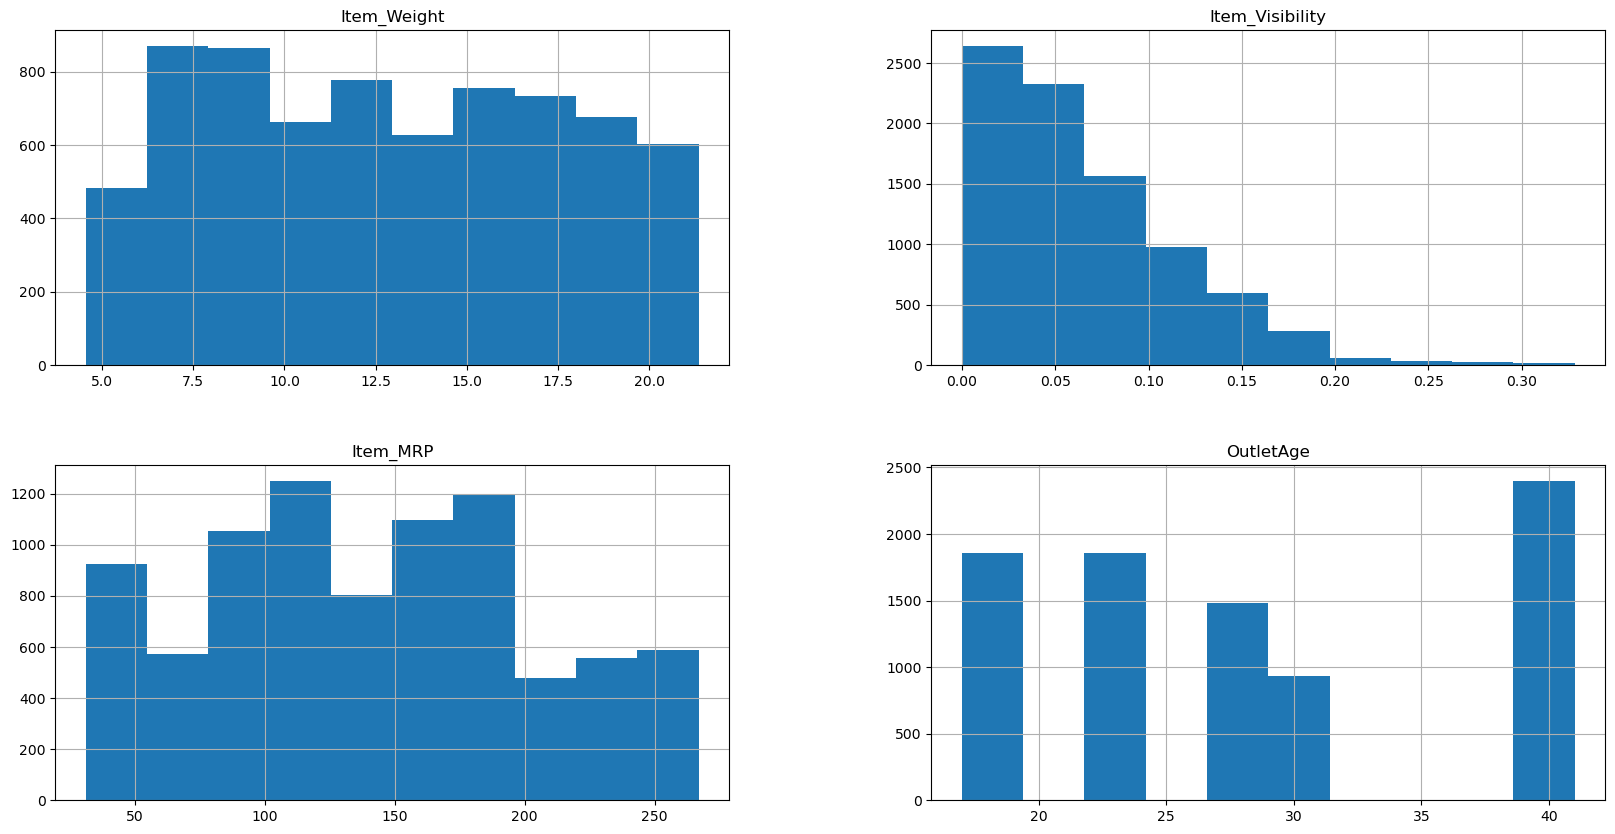

In [ ]:
# Visualize the distributions of numerical features
X[numeric_columns].hist(figsize=(20, 10))

In [ ]:
# Generate descriptive statistics for numerical features
X[numeric_columns].describe()

,Item_Weight,Item_Visibility,Item_MRP,OutletAge
count,7060.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,28.168133
std,4.643456,0.051598,62.275067,8.371760
min,4.555000,0.000000,31.290000,17.000000
25%,8.773750,0.026989,93.826500,22.000000
50%,12.600000,0.053931,143.012800,27.000000
75%,16.850000,0.094585,185.643700,39.000000
max,21.350000,0.328391,266.888400,41.000000


In [ ]:
# Generate an automated exploratory data analysis report
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="EDA Report")
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 48.56it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
average_sale = (
    df.groupby('Item_Type')['Item_Outlet_Sales']
    .mean()
    .sort_values(ascending=False)
)

average_sale

Item_Type
Starchy Foods            2374.332773
Seafood                  2326.065928
Fruits and Vegetables    2289.009592
Snack Foods              2277.321739
Household                2258.784300
Dairy                    2232.542597
Canned                   2225.194904
Breads                   2204.132226
Meat                     2158.977911
Hard Drinks              2139.221622
Frozen Foods             2132.867744
Breakfast                2111.808651
Health and Hygiene       2010.000265
Soft Drinks              2006.511735
Baking Goods             1952.971207
Others                   1926.139702
Name: Item_Outlet_Sales, dtype: float64

In [ ]:
%matplotlib inline

def plot_average_sales(column):
    average_sale = (
        df.groupby(column)['Item_Outlet_Sales']
        .mean()
        .sort_values(ascending=False)
    )

    average_sale.plot(
        kind='bar',
        figsize=(6, 4)
    )

    plt.title(f'Average Sales by {column}')
    plt.xlabel(column)
    plt.ylabel('Average Sales')
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()

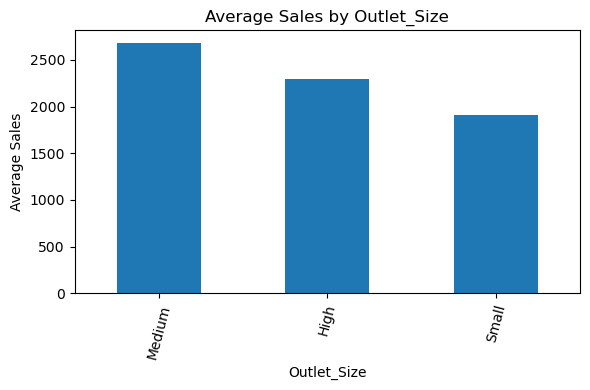

In [ ]:
plot_average_sales('Outlet_Size')

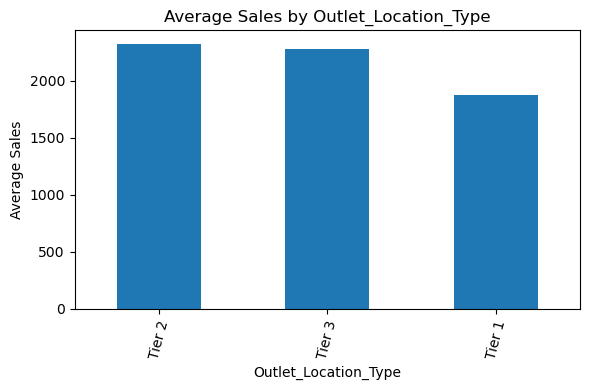

In [ ]:
plot_average_sales('Outlet_Location_Type')

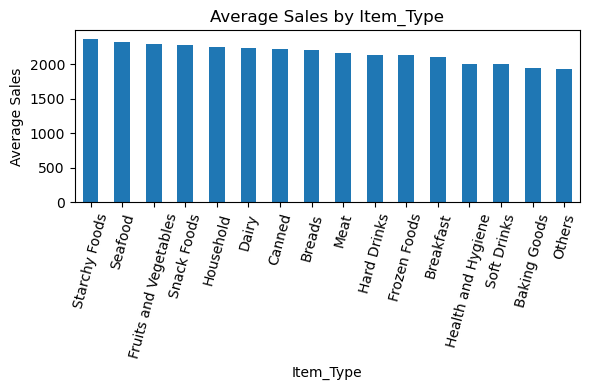

In [ ]:
plot_average_sales('Item_Type')

In [ ]:
df.groupby("Item_Type")[
    "Item_Outlet_Sales"
].mean().sort_values()

Item_Type
Others                   1926.139702
Baking Goods             1952.971207
Soft Drinks              2006.511735
Health and Hygiene       2010.000265
Breakfast                2111.808651
Frozen Foods             2132.867744
Hard Drinks              2139.221622
Meat                     2158.977911
Breads                   2204.132226
Canned                   2225.194904
Dairy                    2232.542597
Household                2258.784300
Snack Foods              2277.321739
Fruits and Vegetables    2289.009592
Seafood                  2326.065928
Starchy Foods            2374.332773
Name: Item_Outlet_Sales, dtype: float64

باید اول ستون تارگت رو جدا کنیم بعد روی داده ها پری پروسس انجام بدیم یعنی

##### 1 - X, y
##### 2 - preproccessing : impute, ...

In [ ]:
X, y = (
   df.drop(['Item_Outlet_Sales'], axis=1)
   , df['Item_Outlet_Sales']
)
# X = df.iloc[:, :-1].values  # .values تبدیل میکنه به ماتریس  numpy
# y = df.iloc[:, -1].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
categorical_cols = ['Item_Fat_Content',
                    'Item_Type',
                    'Outlet_Size',
                    'Outlet_Location_Type',
                    'Outlet_Type']

ordinal_cols = ['Outlet_Size']
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

# ----
ordinal_cols = ['Outlet_Size']
nominal_cols = ['Item_Type', 'Outlet_Location_Type', 'Outlet_Type']

df_ordinal = df[ordinal_cols]
df_nominal = df[nominal_cols]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=3)),
    ('scaler', StandardScaler())
])

In [ ]:
KNNImputer(n_neighbors=3)

KNNImputer(n_neighbors=3)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_columns),
    ('cat', categorical_pipeline, categorical_cols)
])

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=5)

pipe_3 = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

In [ ]:
pipe_3.fit(X_train, y_train)
y_pred = pipe_3.predict(X_test)

c:\Users\ASUS\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ASUS\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\ASUS\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R²:', r2)

MAE: 811.0510841994134
MSE: 1332760.0930327922
RMSE: 1154.4522913627882
R²: 0.5096487229928228


In [ ]:
from sklearn.dummy import DummyRegressor

baseline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))
print("Baseline R²:", r2_score(y_test, baseline_pred))

Baseline MAE: 1321.738728500184
Baseline RMSE: 1651.989750472933
Baseline R²: -0.004083955591431154


In [ ]:
from sklearn.linear_model import LinearRegression

linear_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

linear_pipe.fit(X_train, y_train)

linear_pred = linear_pipe.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R²:", r2_score(y_test, linear_pred))

MAE: 791.5552159830727
RMSE: 1068.8862486532353
R²: 0.5796429745151055


In [ ]:
from sklearn.linear_model import Ridge

ridge_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('model', Ridge(alpha=0.1))
])

ridge_pipe.fit(X_train, y_train)

ridge_pred = ridge_pipe.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

rf_pred = rf_pipe.predict(X_test)

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    }

results = {}
results['KNN'] = evaluate_model(
    pipe_3,
    X_test,
    y_test
)

results['Linear Regression'] = evaluate_model(
    linear_pipe,
    X_test,
    y_test
)
results['Ridge'] = evaluate_model(
    ridge_pipe,
    X_test,
    y_test
)

results['Random Forest'] = evaluate_model(
    rf_pipe,
    X_test,
    y_test
)



In [ ]:
results_df = pd.DataFrame(results).T

results_df.sort_values(
    by='RMSE'
)

,MAE,MSE,RMSE,R²
Linear Regression,791.555216,1.142518e+06,1068.886249,0.579643
Ridge,791.560972,1.142556e+06,1068.904054,0.579629
Random Forest,761.406529,1.190273e+06,1090.996448,0.562073
KNN,811.051084,1.332760e+06,1154.452291,0.509649


In [ ]:
from sklearn.model_selection import cross_validate, KFold
ridge_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('model', Ridge(alpha=1))
])
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_results = cross_validate(
    ridge_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    }
)
results = []

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

for alpha in alphas:

    ridge_pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', Ridge(alpha=alpha))
    ])

    cv_results = cross_validate(
        ridge_pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'MAE': 'neg_mean_absolute_error',
            'RMSE': 'neg_root_mean_squared_error',
            'R2': 'r2'
        }
    )

    results.append({
        'alpha': alpha,
        'MAE_mean': -cv_results['test_MAE'].mean(),
        'MAE_std': cv_results['test_MAE'].std(),
        'RMSE_mean': -cv_results['test_RMSE'].mean(),
        'RMSE_std': cv_results['test_RMSE'].std(),
        'R2_mean': cv_results['test_R2'].mean(),
        'R2_std': cv_results['test_R2'].std()
    })
ridge_results = pd.DataFrame(results)

ridge_results

,alpha,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,0.001,852.983788,16.779349,1148.700323,29.535988,0.552625,0.012255
1,0.010,852.981738,16.779664,1148.699922,29.535558,0.552625,0.012257
2,0.100,852.963204,16.768531,1148.694321,29.523938,0.552629,0.012255
3,1.000,852.810019,16.669746,1148.665046,29.430968,0.552650,0.012243
4,10.000,852.359625,16.387648,1148.928273,29.250094,0.552445,0.012093
5,100.000,852.878938,16.791071,1154.004836,31.357500,0.548559,0.010741
6,1000.000,922.953189,20.013393,1247.724132,39.742257,0.472490,0.007780


In [ ]:
print(X_train[numeric_columns].isnull().sum())
print(X_test[numeric_columns].isnull().sum())

X_train_processed = preprocessor.fit_transform(X_train)

print(type(X_train_processed))
print(X_train_processed.dtype if hasattr(X_train_processed, 'dtype') else 'sparse matrix')

X_train_check = X_train_processed.toarray()

print(np.isnan(X_train_check).sum())
X_test_processed = preprocessor.transform(X_test)

X_test_check = X_test_processed.toarray()

print(np.isnan(X_test_check).sum())
print(type(X_train))
print(type(X_test))

print(X_train.shape)
print(X_test.shape)

Item_Weight        1174
Item_Visibility       0
Item_MRP              0
OutletAge             0
dtype: int64
Item_Weight        289
Item_Visibility      0
Item_MRP             0
OutletAge            0
dtype: int64
<class 'scipy.sparse._csr.csr_matrix'>
float64
0
0
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
(6818, 9)
(1705, 9)
